# 03 Modelling Normal Cycling Counts

This notebook models the expected number of cyclists in each 2-hour interval using the pre-processed AWV data. The aim is to describe normal cycling behaviour across time, location, and direction, so that deviations from expected traffic levels can be identified later.

We start with a baseline Poisson count model and use diagnostics to assess its limitations, including overdispersion, residual patterns, zero counts, and possible non-linear effects. 

Alternative specifications are then evaluated, including models that allow for overdispersion, such as negative binomial. Interactions are considered when they are supported by diagnostics. A more flexible machine learning model is also fitted as a predictive benchmark. 

Model selection is guided by diagnostics, valid information criteria, and out-of-sample performance.


### Packages, path, data reading

In [58]:
#Packages
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance


#Path
project_folder = Path("..")

processed_folder = project_folder / "data" / "processed"

#Data
counts_model_final = pd.read_csv(
    processed_folder / "counts_model_final.csv"
)

counts_model_final["date"] = pd.to_datetime(
    counts_model_final["date"],
    errors="coerce"
)

In [2]:
counts_model_final.info()

pd.set_option("display.max_columns", None)
counts_model_final.head()

<class 'pandas.DataFrame'>
RangeIndex: 4587736 entries, 0 to 4587735
Data columns (total 27 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   site_id                     int64         
 1   direction                   str           
 2   year                        int64         
 3   date                        datetime64[us]
 4   month                       int64         
 5   weekday                     str           
 6   hour_bin                    int64         
 7   count                       float64       
 8   observed_intervals          int64         
 9   total_intervals             int64         
 10  missing_intervals           int64         
 11  missing_share               float64       
 12  expected_intervals_for_row  int64         
 13  count_rescaled              int64         
 14  rescaled                    int64         
 15  longitude                   float64       
 16  latitude                    f

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95
0,1,IN,2022,2022-05-01,5,Sunday,0,13.0,8,8,0,0.0,8,13,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
1,1,IN,2022,2022-05-01,5,Sunday,2,2.0,8,8,0,0.0,8,2,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
2,1,IN,2022,2022-05-01,5,Sunday,4,1.0,8,8,0,0.0,8,1,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
3,1,IN,2022,2022-05-01,5,Sunday,6,6.0,8,8,0,0.0,8,6,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
4,1,IN,2022,2022-05-01,5,Sunday,8,26.0,8,8,0,0.0,8,26,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153


### Time-based model development split

Because the data are ordered in time, the modelling dataset is split chronologically. This avoids using future observations to predict earlier behaviour and gives a more realistic assessment of how well the models generalise to later periods.

The data are divided into three periods:

- **Training period:** May 2022 to April 2024  
  Used to fit the initial model specifications.

- **Validation period:** May 2024 to April 2025  
  Used to compare model specifications, assess diagnostics, and guide model selection.

- **Prediction period:** May 2025 to April 2026  
  Used to estimate expected cycling counts for the period in which deviations will be identified.


In [3]:
def time_split(data):
    training_start = pd.to_datetime("2022-05-01")
    training_end = pd.to_datetime("2024-04-30")

    validation_start = pd.to_datetime("2024-05-01")
    validation_end = pd.to_datetime("2025-04-30")

    prediction_start = pd.to_datetime("2025-05-01")
    prediction_end = pd.to_datetime("2026-04-30")

    train_data = data[
        (data["date"] >= training_start) &
        (data["date"] <= training_end)
    ].copy()

    validation_data = data[
        (data["date"] >= validation_start) &
        (data["date"] <= validation_end)
    ].copy()

    prediction_data = data[
        (data["date"] >= prediction_start) &
        (data["date"] <= prediction_end)
    ].copy()

    return train_data, validation_data, prediction_data

In [4]:
train_data, validation_data, prediction_data = time_split(counts_model_final)

In [5]:
print("Training data:")
print(train_data["date"].min(), "to", train_data["date"].max())
print("Rows:", train_data.shape[0])
print("Sites:", train_data["site_id"].nunique())

print("\nValidation data:")
print(validation_data["date"].min(), "to", validation_data["date"].max())
print("Rows:", validation_data.shape[0])
print("Sites:", validation_data["site_id"].nunique())

print("\nPrediction data:")
print(prediction_data["date"].min(), "to", prediction_data["date"].max())
print("Rows:", prediction_data.shape[0])
print("Sites:", prediction_data["site_id"].nunique())

Training data:
2022-05-01 00:00:00 to 2024-04-30 00:00:00
Rows: 2173859
Sites: 141

Validation data:
2024-05-01 00:00:00 to 2025-04-30 00:00:00
Rows: 1188008
Sites: 139

Prediction data:
2025-05-01 00:00:00 to 2026-04-30 00:00:00
Rows: 1225869
Sites: 144


In [6]:
train_sites = set(train_data["site_id"].unique())
validation_sites = set(validation_data["site_id"].unique())
prediction_sites = set(prediction_data["site_id"].unique())

sites_only_in_validation = validation_sites - train_sites
sites_only_in_prediction = prediction_sites - train_sites

print("Sites in validation but not training:", sorted(sites_only_in_validation))
print("Number:", len(sites_only_in_validation))

print("Sites in prediction but not training:", sorted(sites_only_in_prediction))
print("Number:", len(sites_only_in_prediction))

Sites in validation but not training: []
Number: 0
Sites in prediction but not training: [np.int64(145), np.int64(146), np.int64(147), np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(152)]
Number: 8


In [7]:
sites_in_training_not_validation = train_sites - validation_sites
sites_in_training_not_prediction = train_sites - prediction_sites

print("Sites in training but not validation:", sorted(sites_in_training_not_validation))
print("Number:", len(sites_in_training_not_validation))

print("Sites in training but not prediction:", sorted(sites_in_training_not_prediction))
print("Number:", len(sites_in_training_not_prediction))

Sites in training but not validation: [np.int64(123), np.int64(142)]
Number: 2
Sites in training but not prediction: [np.int64(52), np.int64(95), np.int64(96), np.int64(123), np.int64(142)]
Number: 5


**Important**: Eight sites appear only in the prediction period and were not observed during model development. Since expected behaviour cannot be reliably estimated for sites without historical observations, these sites were excluded from the main deviation-detection analysis.

In [8]:
train_sites = set(train_data["site_id"].unique())

prediction_data_model = prediction_data[
    prediction_data["site_id"].isin(train_sites)
].copy()

new_prediction_sites = prediction_data[
    ~prediction_data["site_id"].isin(train_sites)
].copy()

print("Prediction rows kept:", prediction_data_model.shape[0])
print("Prediction rows excluded because site was unseen in training:", new_prediction_sites.shape[0])
print("Excluded site IDs:", sorted(new_prediction_sites["site_id"].unique()))

Prediction rows kept: 1177575
Prediction rows excluded because site was unseen in training: 48294
Excluded site IDs: [np.int64(145), np.int64(146), np.int64(147), np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(152)]


In [9]:
train_data_model = train_data.copy()
validation_data_model = validation_data.copy()

### Preprocessing for modelling

To make likelihood-based count models computationally feasible, the training and validation data were aggregated over the predictor combinations used in the model. For each group, the total cyclist count and the number of original 2-hour periods were recorded. The logarithm of the number of periods was used as an offset in the count model. This preserves the interpretation of the fitted model as estimating the expected cyclist count per 2-hour interval.


In [10]:
def aggregate_for_count_model(data, aggregation_variables, count_column="count_rescaled"):
    
    aggregated = (
        data
        .groupby(aggregation_variables, observed=True)
        .agg(
            total_count=(count_column, "sum"),
            number_of_periods=(count_column, "size"),
            mean_count=(count_column, "mean"),
            zero_periods=(count_column, lambda x: (x == 0).sum()),
        )
        .reset_index()
    )

    aggregated["zero_share"] = (
        aggregated["zero_periods"] / aggregated["number_of_periods"]
    )

    aggregated["log_number_of_periods"] = np.log(
        aggregated["number_of_periods"]
    )

    return aggregated

In [11]:
#Rounded fuel-price variable for aggregation
for df in [train_data_model, validation_data_model, prediction_data_model]:
    df["fuel_price_petrol_95_rounded"] = (
        df["fuel_price_petrol_95"]
        .round(1)
    )


#Categorical variables for modeling and aggregation
categorical_variables = [
    "site_id",
    "direction",
    "month",
    "weekday",
    "hour_bin",
    "is_public_holiday",
    "is_school_holiday",
]

for variable in categorical_variables:
    train_categories = (
        train_data_model[variable]
        .astype("category")
        .cat.categories
    )

    train_data_model[variable] = pd.Categorical(
        train_data_model[variable],
        categories=train_categories,
    )

    validation_data_model[variable] = pd.Categorical(
        validation_data_model[variable],
        categories=train_categories,
    )

    prediction_data_model[variable] = pd.Categorical(
        prediction_data_model[variable],
        categories=train_categories,
    )

#Aggregation variables
aggregation_variables = [
    "site_id",
    "direction",
    "month",
    "weekday",
    "hour_bin",
    "is_public_holiday",
    "is_school_holiday",
    "fuel_price_petrol_95_rounded",
]

#Aggregation
train_aggregated = aggregate_for_count_model(
    data=train_data_model,
    aggregation_variables=aggregation_variables,
    count_column="count_rescaled",
)

train_aggregated.head()

,site_id,direction,month,weekday,hour_bin,is_public_holiday,is_school_holiday,fuel_price_petrol_95_rounded,total_count,number_of_periods,mean_count,zero_periods,zero_share,log_number_of_periods
0,1,IN,1,Friday,0,0,0,1.6,1,3,0.333333,2,0.666667,1.098612
1,1,IN,1,Friday,0,0,0,1.7,1,3,0.333333,2,0.666667,1.098612
2,1,IN,1,Friday,0,0,1,1.6,0,1,0.000000,1,1.000000,0.000000
3,1,IN,1,Friday,0,0,1,1.7,1,1,1.000000,0,0.000000,0.000000
4,1,IN,1,Friday,2,0,0,1.6,1,3,0.333333,2,0.666667,1.098612


In [12]:
aggregation_summary = pd.DataFrame({
    "dataset": ["Training row-level", "Training aggregated"],
    "rows": [
        train_data_model.shape[0],
        train_aggregated.shape[0],
    ],
    "total_count": [
        train_data_model["count_rescaled"].sum(),
        train_aggregated["total_count"].sum(),
    ],
})

aggregation_summary

,dataset,rows,total_count
0,Training row-level,2173859,42479963
1,Training aggregated,907596,42479963


In [13]:
print("Training aggregated total_count summary:")
print(train_aggregated["total_count"].describe())

print("\nTraining aggregated number_of_periods summary:")
print(train_aggregated["number_of_periods"].describe())

Training aggregated total_count summary:
count    907596.000000
mean         46.804925
std         126.505134
min           0.000000
25%           1.000000
50%           7.000000
75%          38.000000
max        5316.000000
Name: total_count, dtype: float64

Training aggregated number_of_periods summary:
count    907596.000000
mean          2.395184
std           1.612112
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           9.000000
Name: number_of_periods, dtype: float64


In [14]:
print("Training row-level total_count:")
print(train_data_model["count_rescaled"].sum())

print("\nTraining aggregated total_count:")
print(train_aggregated["total_count"].sum())

Training row-level total_count:
42479963

Training aggregated total_count:
42479963


# Poisson model

## Baseline Poisson modell

In [15]:
poisson_baseline_formula = """
total_count ~
    C(hour_bin)
    + C(weekday)
    + C(month)
    + C(site_id)
    + C(direction)
    + C(is_public_holiday)
    + C(is_school_holiday)
    + fuel_price_petrol_95_rounded
"""

poisson_baseline = smf.glm(
    formula=poisson_baseline_formula,
    data=train_aggregated,
    family=sm.families.Poisson(),
    offset=train_aggregated["log_number_of_periods"]
).fit()

print(poisson_baseline.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:            total_count   No. Observations:               907596
Model:                            GLM   Df Residuals:                   907423
Model Family:                 Poisson   Df Model:                          172
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.0158e+07
Date:                Sun, 17 May 2026   Deviance:                   3.7070e+07
Time:                        01:33:03   Pearson chi2:                 4.77e+07
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## Baseline Poisson model diagnostics

### Overdispersion diagnostics

In [16]:
poisson_train = train_aggregated.copy()

poisson_train["fitted_total_count"] = poisson_baseline.predict(
    poisson_train,
    offset=poisson_train["log_number_of_periods"]
)

poisson_train["pearson_residual"] = (
    poisson_train["total_count"] - poisson_train["fitted_total_count"]
) / np.sqrt(poisson_train["fitted_total_count"])

pearson_dispersion = (
    np.sum(poisson_train["pearson_residual"] ** 2)
    / poisson_baseline.df_resid
)

deviance_dispersion = (
    poisson_baseline.deviance
    / poisson_baseline.df_resid
)

pd.DataFrame({
    "diagnostic": [
        "Pearson dispersion",
        "Deviance dispersion",
    ],
    "value": [
        pearson_dispersion,
        deviance_dispersion,
    ],
})

,diagnostic,value
0,Pearson dispersion,52.598185
1,Deviance dispersion,40.852249


### Zero counts diagnostics

In [17]:
train_row_predicted = poisson_baseline.predict(
    train_data_model,
    offset=np.zeros(train_data_model.shape[0])
)

observed_zero_share_train = (
    train_data_model["count_rescaled"] == 0
).mean()

predicted_zero_share_train = np.exp(-train_row_predicted).mean()

print("Observed row-level zero share:", observed_zero_share_train)
print("Predicted row-level zero share under Poisson:", predicted_zero_share_train)
print("Difference:", observed_zero_share_train - predicted_zero_share_train)

Observed row-level zero share: 0.28256524457198007
Predicted row-level zero share under Poisson: 0.0817097954499815
Difference: 0.20085544912199857


### Deviance residuals plot

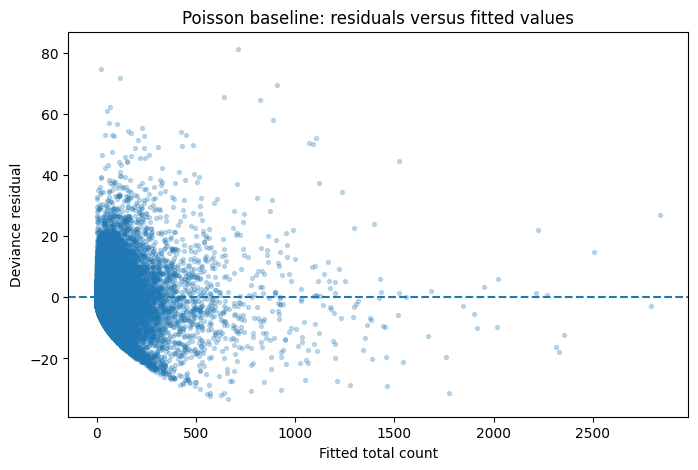

In [18]:
poisson_train["deviance_residual"] = poisson_baseline.resid_deviance

plot_sample = poisson_train.sample(
    n=min(50000, poisson_train.shape[0]),
    random_state=123
)

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_sample["fitted_total_count"],
    plot_sample["deviance_residual"],
    alpha=0.25,
    s=8
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted total count")
plt.ylabel("Deviance residual")
plt.title("Poisson baseline: residuals versus fitted values")

plt.show()


Model diagnostics were conducted on the training data. Pearson and deviance dispersion statistics were computed on the aggregated training data, since this is the data used for estimation. In addition, the observed and predicted zero-count shares were compared at the original row level, because zero counts are meaningful for individual 2-hour intervals. Residual plot was produced using a random sample of aggregated training rows.

The diagnostics show that the baseline Poisson model is not adequate for these data. The Pearson dispersion statistic was 52.60 and the deviance dispersion statistic was 40.85, both far above the value of 1 expected under a well-fitting Poisson model. This indicates substantial overdispersion. The model also underpredicted zero counts: the observed row-level zero-count share was 28.26%, while the Poisson-predicted zero-count share was only 8.17%. The residual plot further showed a structured and widely spread residual pattern.

# Negative binomial model

## Negative binomial models

In [19]:
nb_baseline = """
total_count ~
    C(hour_bin)
    + C(weekday)
    + C(month)
    + C(site_id)
    + C(direction)
    + C(is_public_holiday)
    + C(is_school_holiday)
    + fuel_price_petrol_95_rounded
"""

nb_alt1 = """
total_count ~
    C(hour_bin)
    + C(weekday)
    + C(month)
    + C(site_id)
    + C(direction)
    + C(is_public_holiday)
    + C(is_school_holiday)
    + fuel_price_petrol_95_rounded
    + C(hour_bin):C(weekday)
"""

nb_alt2 = """
total_count ~
    C(hour_bin)
    + C(weekday)
    + C(month)
    + C(site_id)
    + C(direction)
    + C(is_public_holiday)
    + C(is_school_holiday)
    + fuel_price_petrol_95_rounded
    + C(hour_bin):C(direction)
"""


nb_alt3 = """
total_count ~
    C(hour_bin)
    + C(weekday)
    + C(month)
    + C(site_id)
    + C(direction)
    + C(is_public_holiday)
    + C(is_school_holiday)
    + fuel_price_petrol_95_rounded
    + C(hour_bin):C(weekday)
    + C(hour_bin):C(direction)
"""


In [ ]:
def fit_negative_binomial_model(formula, data, model_name):

    model = smf.negativebinomial(
        formula=formula,
        data=data,
        offset=data["log_number_of_periods"]
    )

    result = model.fit(
        method="lbfgs",
        maxiter=200,
        disp=False
    )

    print(result.summary())

    return result

In [23]:
nb_baseline = fit_negative_binomial_model(
    formula=nb_baseline,
    data=train_aggregated,
    model_name="Negative binomial baseline"
)

In [24]:
nb_alt1 = fit_negative_binomial_model(
    formula=nb_alt1,
    data=train_aggregated,
    model_name="Negative binomial with hour × weekday interaction"
)

In [25]:
nb_alt2 = fit_negative_binomial_model(
    formula=nb_alt2,
    data=train_aggregated,
    model_name="Negative binomial with hour × direction interaction"
)

In [26]:
nb_alt3 = fit_negative_binomial_model(
    formula=nb_alt3,
    data=train_aggregated,
    model_name="Negative binomial with both interactions"
)

## Model comparison

In [27]:
nb_models = {
    "NB baseline": nb_baseline,
    "NB + hour × weekday interaction": nb_alt1,
    "NB + hour × direction": nb_alt2,
    "NB + both interactions": nb_alt3,
}

In [28]:
def likelihood_ratio_test(reduced_model, full_model):
    lr_stat = 2 * (full_model.llf - reduced_model.llf)
    df_diff = full_model.df_model - reduced_model.df_model
    p_value = stats.chi2.sf(lr_stat, df_diff)

    return {
        "lr_statistic": lr_stat,
        "df_difference": df_diff,
        "p_value": p_value,
    }

In [29]:
lr_tests = []

lr_tests.append({
    "comparison": "NB baseline vs NB + hour × weekday",
    **likelihood_ratio_test(nb_baseline, nb_alt1)
})

lr_tests.append({
    "comparison": "NB baseline vs NB + hour × direction",
    **likelihood_ratio_test(nb_baseline, nb_alt2)
})

lr_tests.append({
    "comparison": "NB + hour × weekday vs NB + both interactions",
    **likelihood_ratio_test(nb_alt1, nb_alt3)
})

lr_tests.append({
    "comparison": "NB + hour × direction vs NB + both interactions",
    **likelihood_ratio_test(nb_alt2, nb_alt3)
})

lr_tests = pd.DataFrame(lr_tests)

lr_tests

,comparison,lr_statistic,df_difference,p_value
0,NB baseline vs NB + hour × weekday,60787.572043,66.0,0.000000e+00
1,NB baseline vs NB + hour × direction,125.793017,11.0,1.233227e-21
2,NB + hour × weekday vs NB + both interactions,105.155657,11.0,1.692557e-17
3,NB + hour × direction vs NB + both interactions,60766.934684,66.0,0.000000e+00


In [30]:
nb_comparison = []

for name, model in nb_models.items():
    nb_comparison.append({
        "model": name,
        "log_likelihood": model.llf,
        "df_model": model.df_model,
        "aic": model.aic,
        "bic": model.bic,
        "alpha": model.params.get("alpha", np.nan),
    })

nb_comparison = pd.DataFrame(nb_comparison)

nb_comparison = nb_comparison.sort_values("aic").reset_index(drop=True)

nb_comparison

,model,log_likelihood,df_model,aic,bic,alpha
0,NB + both interactions,-3.365514e+06,249.0,6.731531e+06,6.734472e+06,1.538889
1,NB + hour × weekday interaction,-3.365567e+06,238.0,6.731614e+06,6.734426e+06,1.538836
2,NB + hour × direction,-3.395898e+06,183.0,6.792166e+06,6.794334e+06,1.650113
3,NB baseline,-3.395961e+06,172.0,6.792270e+06,6.794309e+06,1.650236


### Zero counts diagnostics

In [31]:
predicted_train_nb_alt3 = nb_alt3.predict(
    train_data_model,
    offset=np.zeros(train_data_model.shape[0])
)

alpha_nb_alt3 = nb_alt3.params["alpha"]

predicted_zero_probability_train_nb_alt3 = (
    1 + alpha_nb_alt3 * predicted_train_nb_alt3
) ** (-1 / alpha_nb_alt3)

observed_zero_share_train = (
    train_data_model["count_rescaled"] == 0
).mean()

predicted_zero_share_train_nb_alt3 = (
    predicted_zero_probability_train_nb_alt3.mean()
)

print("Observed row-level zero share, train:", observed_zero_share_train)
print("Predicted row-level zero share, NB alternative 3:", predicted_zero_share_train_nb_alt3)
print(
    "Difference observed - predicted:",
    observed_zero_share_train - predicted_zero_share_train_nb_alt3
)
print("Estimated alpha:", alpha_nb_alt3)

Observed row-level zero share, train: 0.28256524457198007
Predicted row-level zero share, NB alternative 3: 0.25018527885140884
Difference observed - predicted: 0.032379965720571224
Estimated alpha: 1.5388888445768467


**Negative binomial model substantially improved the zero-count fit.**

# Gradient Boosting method

Defining features

In [59]:
hgb_features = [
    "site_id",
    "direction",
    "month",
    "weekday",
    "hour_bin",
    "is_public_holiday",
    "is_school_holiday",
    "fuel_price_petrol_95",
]

hgb_target = "count_rescaled"

categorical_hgb_features = [
    "site_id",
    "direction",
    "month",
    "weekday",
    "hour_bin",
    "is_public_holiday",
    "is_school_holiday",
]

numeric_hgb_features = [
    "fuel_price_petrol_95",
]

X_train_hgb = train_data_model[hgb_features].copy()
y_train_hgb = train_data_model[hgb_target].copy()

X_validation_hgb = validation_data_model[hgb_features].copy()
y_validation_hgb = validation_data_model[hgb_target].copy()

Building pipeline

In [60]:
def build_hgb_pipeline(
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=50,
):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_hgb_features,
            ),
            (
                "numeric",
                "passthrough",
                numeric_hgb_features,
            ),
        ]
    )

    model = HistGradientBoostingRegressor(
        loss="poisson",
        learning_rate=learning_rate,
        max_iter=300,
        max_leaf_nodes=max_leaf_nodes,
        min_samples_leaf=min_samples_leaf,
        l2_regularization=0.1,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=123,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    return pipeline

Parameter settings

In [61]:
hgb_settings = [
    {
        "model_name": "HGB small trees",
        "learning_rate": 0.05,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 100,
    },
    {
        "model_name": "HGB medium trees",
        "learning_rate": 0.05,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 50,
    },
    {
        "model_name": "HGB slower learning",
        "learning_rate": 0.03,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 50,
    },
]

Selecting parameter set

In [62]:
hgb_results = []
hgb_fitted_models = {}

for setting in hgb_settings:

    pipeline = build_hgb_pipeline(
        learning_rate=setting["learning_rate"],
        max_leaf_nodes=setting["max_leaf_nodes"],
        min_samples_leaf=setting["min_samples_leaf"],
    )

    pipeline.fit(X_train_hgb, y_train_hgb)

    validation_predicted = pipeline.predict(X_validation_hgb)

    validation_predicted = np.clip(
        validation_predicted,
        1e-9,
        None,
    )

    hgb_results.append({
        "model": setting["model_name"],
        "learning_rate": setting["learning_rate"],
        "max_leaf_nodes": setting["max_leaf_nodes"],
        "min_samples_leaf": setting["min_samples_leaf"],
        "validation_mae": mean_absolute_error(
            y_validation_hgb,
            validation_predicted,
        ),
        "validation_rmse": np.sqrt(
            mean_squared_error(
                y_validation_hgb,
                validation_predicted,
            )
        ),
        "validation_mean_poisson_deviance": mean_poisson_deviance(
            y_validation_hgb,
            validation_predicted,
        ),
        "mean_observed": y_validation_hgb.mean(),
        "mean_predicted": validation_predicted.mean(),
        "mean_error_observed_minus_predicted": (
            y_validation_hgb - validation_predicted
        ).mean(),
    })

    hgb_fitted_models[setting["model_name"]] = pipeline


hgb_results = pd.DataFrame(hgb_results)

hgb_results = hgb_results.sort_values(
    "validation_mean_poisson_deviance"
).reset_index(drop=True)

hgb_results

,model,learning_rate,max_leaf_nodes,min_samples_leaf,validation_mae,validation_rmse,validation_mean_poisson_deviance,mean_observed,mean_predicted,mean_error_observed_minus_predicted
0,HGB medium trees,0.05,31,50,12.383822,33.629838,14.924384,22.536608,18.897544,3.639064
1,HGB slower learning,0.03,31,50,13.749790,35.285404,17.883853,22.536608,18.497067,4.039541
2,HGB small trees,0.05,15,100,14.287826,36.498485,18.927143,22.536608,18.419923,4.116685


In [63]:
best_hgb = hgb_results.loc[0, "model"]

best_hgb_pipeline = hgb_fitted_models[best_hgb]

best_hgb

'HGB medium trees'

# Comparing the Negative Binomial model and Gradient Boosting model

In [ ]:
#Predictions from NB with both interactions
nb_alt3_validation_predicted = nb_alt3.predict(
    validation_data_model,
    offset=np.zeros(validation_data_model.shape[0])
)

nb_alt3_validation_predicted = np.clip(
    nb_alt3_validation_predicted,
    1e-9,
    None
)

#Predictions from best HGB
best_hgb_validation_predicted = best_hgb_pipeline.predict(
    X_validation_hgb
)

best_hgb_validation_predicted = np.clip(
    best_hgb_validation_predicted,
    1e-9,
    None
)

#Observed validation counts
validation_observed = validation_data_model["count_rescaled"]


In [ ]:

model_comparison = pd.DataFrame({
    "model": [
        "Negative binomial: both interactions",
        f"Best HGB: {best_hgb}",
    ],
    "validation_mae": [
        mean_absolute_error(
            validation_observed,
            nb_alt3_validation_predicted,
        ),
        mean_absolute_error(
            validation_observed,
            best_hgb_validation_predicted,
        ),
    ],
    "validation_rmse": [
        np.sqrt(
            mean_squared_error(
                validation_observed,
                nb_alt3_validation_predicted,
            )
        ),
        np.sqrt(
            mean_squared_error(
                validation_observed,
                best_hgb_validation_predicted,
            )
        ),
    ],
    "validation_mean_poisson_deviance": [
        mean_poisson_deviance(
            validation_observed,
            nb_alt3_validation_predicted,
        ),
        mean_poisson_deviance(
            validation_observed,
            best_hgb_validation_predicted,
        ),
    ],
    "mean_observed": [
        validation_observed.mean(),
        validation_observed.mean(),
    ],
    "mean_predicted": [
        nb_alt3_validation_predicted.mean(),
        best_hgb_validation_predicted.mean(),
    ],
    "mean_error_observed_minus_predicted": [
        (validation_observed - nb_alt3_validation_predicted).mean(),
        (validation_observed - best_hgb_validation_predicted).mean(),
    ],
})

model_comparison

,model,validation_mae,validation_rmse,validation_mean_poisson_deviance,mean_observed,mean_predicted,mean_error_observed_minus_predicted
0,Negative binomial: both interactions,16.516146,39.812733,21.844326,22.536608,22.297048,0.239560
1,Best HGB: HGB medium trees,12.495373,34.004821,14.963154,22.536608,19.119490,3.417118


The histogram gradient boosting model achieved better validation performance in terms of MAE, RMSE and mean Poisson deviance, indicating that nonlinearities and interactions are relevant for prediction.The negative binomial model had weaker individual prediction performance but preserved the average traffic level more closely and provided a more interpretable count-model framework.

### Validation bias check

In [ ]:
def bias_function(
    data,
    group_variable,
    observed_column,
    prediction_columns,
):
    bias_data = data.copy()

    aggregation_dict = {
        "observed_mean": (observed_column, "mean"),
        "rows": (observed_column, "size"),
    }

    for prediction_column in prediction_columns:
        aggregation_dict[f"{prediction_column}_mean"] = (
            prediction_column,
            "mean",
        )

    bias_summary = (
        bias_data
        .groupby(group_variable)
        .agg(**aggregation_dict)
        .reset_index()
    )

    for prediction_column in prediction_columns:
        bias_summary[f"{prediction_column}_mean_error"] = (
            bias_summary["observed_mean"]
            - bias_summary[f"{prediction_column}_mean"]
        )

        bias_summary[f"{prediction_column}_absolute_mean_error"] = (
            bias_summary[f"{prediction_column}_mean_error"].abs()
        )

    return bias_summary

In [ ]:
validation_bias_check = validation_data_model.copy()

validation_bias_check["nb_alt3_predicted"] = nb_alt3_validation_predicted
validation_bias_check["best_hgb_predicted"] = best_hgb_validation_predicted

In [ ]:
prediction_columns = [
    "nb_alt3_predicted",
    "best_hgb_predicted",
]

bias_by_hour = bias_function(
    data=validation_bias_check,
    group_variable="hour_bin",
    observed_column="count_rescaled",
    prediction_columns=prediction_columns,
)

bias_by_hour

,hour_bin,observed_mean,rows,nb_alt3_predicted_mean,best_hgb_predicted_mean,nb_alt3_predicted_mean_error,nb_alt3_predicted_absolute_mean_error,best_hgb_predicted_mean_error,best_hgb_predicted_absolute_mean_error
0,0,2.712868,98958,2.416344,2.335327,0.296524,0.296524,0.377541,0.377541
1,2,1.469062,98682,1.492416,1.621998,-0.023353,0.023353,-0.152936,0.152936
2,4,4.320748,98978,5.096287,4.065436,-0.775539,0.775539,0.255312,0.255312
3,6,24.130543,99040,27.453632,22.264897,-3.323089,3.323089,1.865646,1.865646
4,8,35.692686,99042,34.830335,30.302255,0.862350,0.862350,5.390431,5.390431
5,10,29.136059,99038,29.819182,24.964191,-0.683123,0.683123,4.171868,4.171868
6,12,35.667649,99040,36.557371,29.463749,-0.889721,0.889721,6.203901,6.203901
7,14,41.860831,99038,41.773339,34.178259,0.087492,0.087492,7.682572,7.682572
8,16,49.874743,99044,47.758224,41.016607,2.116519,2.116519,8.858136,8.858136
9,18,24.964875,99046,22.030518,21.168152,2.934357,2.934357,3.796723,3.796723


In [ ]:
bias_by_weekday = bias_function(
    data=validation_bias_check,
    group_variable="weekday",
    observed_column="count_rescaled",
    prediction_columns=prediction_columns,
)

bias_by_weekday

,weekday,observed_mean,rows,nb_alt3_predicted_mean,best_hgb_predicted_mean,nb_alt3_predicted_mean_error,nb_alt3_predicted_absolute_mean_error,best_hgb_predicted_mean_error,best_hgb_predicted_absolute_mean_error
0,Friday,23.706237,169334,23.577114,20.454030,0.129124,0.129124,3.252208,3.252208
1,Monday,23.753935,169240,22.747760,20.184979,1.006175,1.006175,3.568957,3.568957
2,Saturday,17.751556,169346,17.509929,14.569155,0.241627,0.241627,3.182401,3.182401
3,Sunday,17.052194,169082,15.314359,13.032407,1.737834,1.737834,4.019787,4.019787
4,Thursday,25.250351,169326,24.988183,21.394116,0.262169,0.262169,3.856236,3.856236
5,Tuesday,25.247786,169158,26.537550,22.167453,-1.289764,1.289764,3.080333,3.080333
6,Wednesday,24.944662,172522,25.341851,21.975651,-0.397188,0.397188,2.969011,2.969011


In [ ]:
bias_by_site = bias_function(
    data=validation_bias_check,
    group_variable="site_id",
    observed_column="count_rescaled",
    prediction_columns=prediction_columns,
)

bias_by_site

,site_id,observed_mean,rows,nb_alt3_predicted_mean,best_hgb_predicted_mean,nb_alt3_predicted_mean_error,nb_alt3_predicted_absolute_mean_error,best_hgb_predicted_mean_error,best_hgb_predicted_absolute_mean_error
0,1,16.989267,8758,17.453179,15.814777,-0.463913,0.463913,1.174490,1.174490
1,2,33.716602,8758,29.403445,28.637049,4.313157,4.313157,5.079553,5.079553
2,3,32.636675,8758,34.675648,26.999496,-2.038973,2.038973,5.637179,5.637179
3,4,7.900776,8758,7.154525,7.491857,0.746251,0.746251,0.408919,0.408919
4,5,8.217972,8758,8.571428,7.491857,-0.353456,0.353456,0.726115,0.726115
5,6,16.051153,8758,13.810966,13.765131,2.240187,2.240187,2.286022,2.286022
6,7,14.290249,8758,15.139961,12.677620,-0.849712,0.849712,1.612629,1.612629
7,8,15.440854,8758,15.421674,13.267295,0.019180,0.019180,2.173559,2.173559
8,9,17.150719,8758,17.753743,15.038281,-0.603024,0.603024,2.112438,2.112438
9,10,14.332839,8758,11.157450,13.473990,3.175388,3.175388,0.858848,0.858848


In [ ]:
site_calibration_summary = pd.DataFrame({
    "model": [
        "Negative binomial: both interactions",
        f"Best HGB: {best_hgb}",
    ],
    "mean_abs_site_bias": [
        bias_by_site["nb_alt3_predicted_absolute_mean_error"].mean(),
        bias_by_site["best_hgb_predicted_absolute_mean_error"].mean(),
    ],
    "median_abs_site_bias": [
        bias_by_site["nb_alt3_predicted_absolute_mean_error"].median(),
        bias_by_site["best_hgb_predicted_absolute_mean_error"].median(),
    ],
    "max_abs_site_bias": [
        bias_by_site["nb_alt3_predicted_absolute_mean_error"].max(),
        bias_by_site["best_hgb_predicted_absolute_mean_error"].max(),
    ],
    "sites_with_abs_bias_above_5": [
        (bias_by_site["nb_alt3_predicted_absolute_mean_error"] > 5).sum(),
        (bias_by_site["best_hgb_predicted_absolute_mean_error"] > 5).sum(),
    ],
    "sites_with_abs_bias_above_10": [
        (bias_by_site["nb_alt3_predicted_absolute_mean_error"] > 10).sum(),
        (bias_by_site["best_hgb_predicted_absolute_mean_error"] > 10).sum(),
    ],
})

site_calibration_summary

,model,mean_abs_site_bias,median_abs_site_bias,max_abs_site_bias,sites_with_abs_bias_above_5,sites_with_abs_bias_above_10
0,Negative binomial: both interactions,4.720555,2.098498,59.283149,33,18
1,Best HGB: HGB medium trees,5.154803,2.458119,43.218159,39,19


In [ ]:
bias_by_site["better_calibrated_model"] = np.where(
    bias_by_site["nb_alt3_predicted_absolute_mean_error"]
    < bias_by_site["best_hgb_predicted_absolute_mean_error"],
    "Negative binomial",
    "Best HGB",
)

bias_by_site["better_calibrated_model"].value_counts()

better_calibrated_model
Negative binomial    83
Best HGB             56
Name: count, dtype: int64

The validation bias checks show that the histogram gradient boosting model has lower overall validation error, but it underpredicts the average number of cyclists across most daytime periods and across all weekdays. The negative binomial model with the hour-by-weekday and direction-by-hour interactions has higher overall prediction error, but it follows the average hourly, weekday and sites traffic profiles better. For this reason, the negative binomial model is more suitable as the main normal-count model.

# Refitting the Negative Binomial model on the full model-development period

In [46]:
model_development_data = pd.concat(
    [
        train_data_model,
        validation_data_model,
    ],
    ignore_index=True,
)


In [47]:
final_model_development_aggregated = aggregate_for_count_model(
    model_development_data,
    aggregation_variables
)

In [49]:
aggregation_check = pd.DataFrame({
    "dataset": [
        "Model development row-level",
        "Model development aggregated",
    ],
    "rows": [
        model_development_data.shape[0],
        final_model_development_aggregated.shape[0],
    ],
    "total_count": [
        model_development_data["count_rescaled"].sum(),
        final_model_development_aggregated["total_count"].sum(),
    ],
})

aggregation_check

,dataset,rows,total_count
0,Model development row-level,3361867,69253634
1,Model development aggregated,1253486,69253634


In [50]:
final_nb_formula = """
total_count ~
    C(hour_bin)
    + C(weekday)
    + C(month)
    + C(site_id)
    + C(direction)
    + C(is_public_holiday)
    + C(is_school_holiday)
    + fuel_price_petrol_95_rounded
    + C(hour_bin):C(weekday)
    + C(hour_bin):C(direction)
"""

final_nb_model = fit_negative_binomial_model(
    formula=final_nb_formula,
    data=final_model_development_aggregated,
    model_name="Final negative binomial with both interactions"
)

In [51]:
prediction_expected = prediction_data_model.copy()

prediction_expected["expected_count"] = final_nb_model.predict(
    prediction_expected,
    offset=np.zeros(prediction_expected.shape[0])
)

prediction_expected["expected_count"] = np.clip(
    prediction_expected["expected_count"],
    1e-9,
    None
)

In [52]:
prediction_expected.to_csv(
    processed_folder / "expected_counts.csv",
    index=False
)